# SupportOps AI - Baseline Ticket Classification

## Objective

Build a baseline NLP classification model that predicts the type of a
customer support ticket from its text.

### Pipeline

Ticket Text → TF-IDF → Logistic Regression → Ticket Type

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
DATA_PATH = "../data/processed/ticket_classification_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (8469, 3)


,ticket_id,ticket_text,ticket_type
0,1,Product setup I'm having an issue with the {pr...,Technical issue
1,2,Peripheral compatibility I'm having an issue w...,Technical issue
2,3,Network problem I'm facing a problem with my {...,Technical issue
3,4,Account access I'm having an issue with the {p...,Billing inquiry
4,5,Data loss I'm having an issue with the {produc...,Billing inquiry


Verify the data before training

In [3]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTicket classes:")
print(df["ticket_type"].value_counts())

Dataset shape: (8469, 3)

Missing values:
ticket_id      0
ticket_text    0
ticket_type    0
dtype: int64

Ticket classes:
ticket_type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


In [4]:
X = df["ticket_text"]
y = df["ticket_type"]

In [5]:
print("Input examples:", X.shape[0])
print("Target examples:", y.shape[0])

Input examples: 8469
Target examples: 8469


Split the dataset

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 6775
Testing samples: 1694


Verify stratification

In [8]:
train_distribution = (
    y_train.value_counts(normalize=True) * 100
)

test_distribution = (
    y_test.value_counts(normalize=True) * 100
)

distribution_comparison = pd.DataFrame({
    "Train %": train_distribution,
    "Test %": test_distribution
})

distribution_comparison

,Train %,Test %
ticket_type,,
Refund request,20.678967,20.720189
Technical issue,20.634686,20.602125
Cancellation request,20.014760,20.011806
Product inquiry,19.380074,19.362456
Billing inquiry,19.291513,19.303424


Create the TF-IDF vectorizer

In [9]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

Build the Pipeline

In [10]:
baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

Train the model

In [11]:
baseline_model.fit(
    X_train,
    y_train
)

print("Baseline model trained successfully!")

Baseline model trained successfully!


Generate Predictions

In [12]:
y_pred = baseline_model.predict(X_test)

print("Predictions generated!")

Predictions generated!


Calculating accuracy score

In [14]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.2048


Precision, Recall and F1

In [15]:
precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Macro F1:  {f1:.4f}")

Accuracy:  0.2048
Precision: 0.2053
Recall:    0.2049
Macro F1:  0.2050


Generating full classification report

In [16]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

                      precision    recall  f1-score   support

     Billing inquiry     0.2074    0.2049    0.2062       327
Cancellation request     0.2118    0.2006    0.2061       339
     Product inquiry     0.2166    0.2073    0.2118       328
      Refund request     0.1791    0.1852    0.1821       351
     Technical issue     0.2118    0.2264    0.2188       349

            accuracy                         0.2048      1694
           macro avg     0.2053    0.2049    0.2050      1694
        weighted avg     0.2051    0.2048    0.2049      1694



Creating the confusion matrix

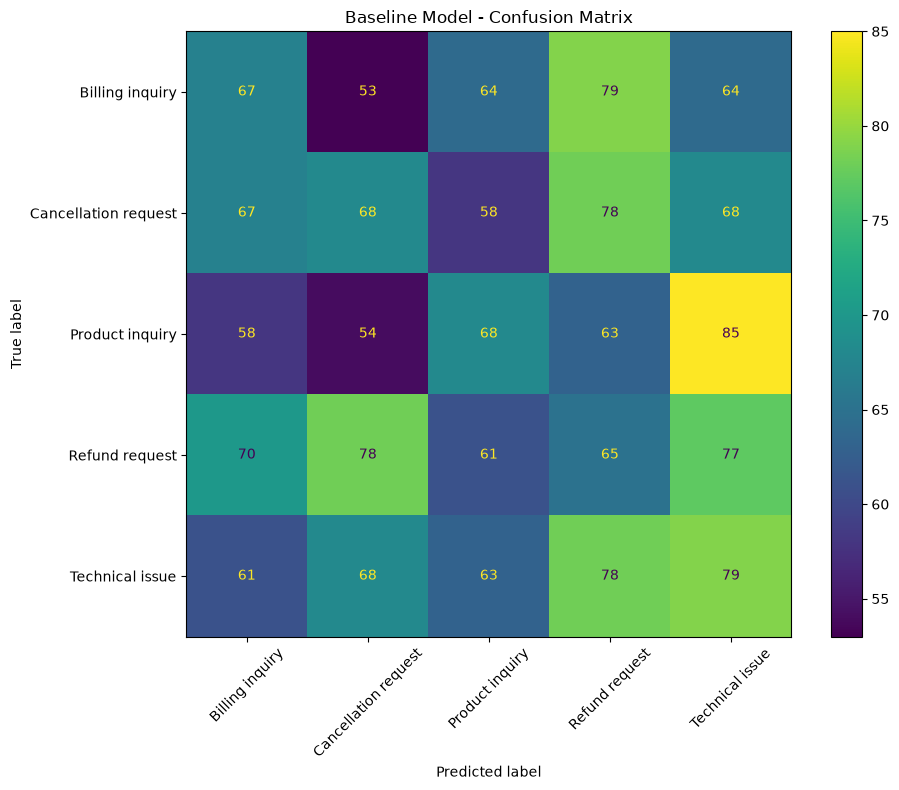

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45,
    ax=ax
)

plt.title("Baseline Model - Confusion Matrix")
plt.tight_layout()
plt.show()

Creating a compact metrics table

In [18]:
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_df

,Metric,Score
0,Accuracy,0.204841
1,Macro Precision,0.205338
2,Macro Recall,0.204869
3,Macro F1,0.204992


Inspect actual predictions

In [19]:
results_df = pd.DataFrame({
    "ticket_text": X_test,
    "actual": y_test,
    "predicted": y_pred
})

results_df.head(10)

,ticket_text,actual,predicted
6510,Installation support I'm having an issue with ...,Product inquiry,Cancellation request
4921,Refund request I'm having an issue with the {p...,Refund request,Cancellation request
871,Cancellation request I'm having an issue with ...,Billing inquiry,Cancellation request
6086,Account access I'm having an issue with the {p...,Product inquiry,Billing inquiry
3305,Cancellation request I'm having an issue with ...,Refund request,Cancellation request
7739,Peripheral compatibility I'm having an issue w...,Cancellation request,Technical issue
6339,Refund request I'm having an issue with the {p...,Technical issue,Cancellation request
7811,Network problem I'm having an issue with the {...,Technical issue,Product inquiry
6844,Delivery problem I'm facing issues logging int...,Refund request,Billing inquiry
563,Battery life I'm having an issue with the {pro...,Billing inquiry,Cancellation request


In [20]:
errors_df = results_df[
    results_df["actual"] != results_df["predicted"]
]

print("Number of incorrect predictions:", len(errors_df))

errors_df.head(20)

Number of incorrect predictions: 1347


,ticket_text,actual,predicted
6510,Installation support I'm having an issue with ...,Product inquiry,Cancellation request
4921,Refund request I'm having an issue with the {p...,Refund request,Cancellation request
871,Cancellation request I'm having an issue with ...,Billing inquiry,Cancellation request
6086,Account access I'm having an issue with the {p...,Product inquiry,Billing inquiry
3305,Cancellation request I'm having an issue with ...,Refund request,Cancellation request
7739,Peripheral compatibility I'm having an issue w...,Cancellation request,Technical issue
6339,Refund request I'm having an issue with the {p...,Technical issue,Cancellation request
7811,Network problem I'm having an issue with the {...,Technical issue,Product inquiry
6844,Delivery problem I'm facing issues logging int...,Refund request,Billing inquiry
563,Battery life I'm having an issue with the {pro...,Billing inquiry,Cancellation request


Inspect individual mistakes

In [21]:
for _, row in errors_df.head(5).iterrows():

    print("=" * 80)

    print("TICKET:")
    print(row["ticket_text"])

    print("\nACTUAL:")
    print(row["actual"])

    print("\nPREDICTED:")
    print(row["predicted"])

    print()

TICKET:
Installation support I'm having an issue with the {product_purchased}. Please assist. This problem started occurring after the recent software update. I haven't made any other changes to the device.

ACTUAL:
Product inquiry

PREDICTED:
Cancellation request

TICKET:
Refund request I'm having an issue with the {product_purchased}. Please assist. I've recently updated the firmware of my {product_purchased}, and the issue started happening afterward. Could it be related to the update?

ACTUAL:
Refund request

PREDICTED:
Cancellation request

TICKET:
Cancellation request I'm having an issue with the {product_purchased}. Please assist. This problem started occurring after the recent software update. I haven't made any other changes to the device.

ACTUAL:
Billing inquiry

PREDICTED:
Cancellation request

TICKET:
Account access I'm having an issue with the {product_purchased}. Please assist. {product_name}'s "Product Name" contains a product identifier, which you can use to verify the